##### imports

# To-Do:
- black & white color grading
- different/heavier models
    - ResNet50V2
    - DenseNet169
    - EfficientNetV2B1
- XAI

In [1]:
import tensorflow as tf
import keras
from keras.saving import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers,models
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
#from google.colab import drive
#drive.mount(' /content/drive')
import random
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import Handwriting_XAI2 as xai

In [2]:
def process_image(args):
    img_path, output_path, target_size, bw_threshold = args

    with Image.open(img_path) as img:
        img = img.convert("RGB")
        w, h = img.size

        if h > w:
            # Tall image → crop from bottom
            img = img.crop((0, 0, w, w))   # keep top square
            squared_img = img

        else:
            # Wide image → pad normally
            max_dim = max(w, h)

            squared_img = Image.new("RGB", (max_dim, max_dim), (255,255,255))
            squared_img.paste(img, (0,0))

        if target_size:
            squared_img = squared_img.resize(target_size, Image.LANCZOS)

        # Convert to pure black and white (no greyscale) via thresholding
        greyscale = squared_img.convert("L")
        bw_img = greyscale.point(lambda p: 255 if p >= bw_threshold else 0, "1")

        bw_img.save(output_path)


def process_dataset(input_root, output_root, target_size=None, workers=8, bw_threshold=128):

    tasks = []

    for split in ["train", "val", "test"]:
        split_path = os.path.join(input_root, split)

        for class_name in os.listdir(split_path):

            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            output_class_path = os.path.join(output_root, split, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png','.jpg','.jpeg')):

                    img_path = os.path.join(class_path, img_name)
                    output_path = os.path.join(output_class_path, img_name)

                    tasks.append((img_path, output_path, target_size, bw_threshold))

    with ProcessPoolExecutor(max_workers=workers) as executor:
        list(tqdm(executor.map(process_image, tasks), total=len(tasks)))

In [3]:
def load_bw_as_rgb(img, target_size):
    "Duplicates one-channel of image into 3-channels"
    # Expects an already-decoded tensor, not a file path
    img = tf.image.resize(img, target_size)
    img = tf.image.rgb_to_grayscale(img)        # (H, W, 3) → (H, W, 1)
    img = tf.repeat(img, repeats=3, axis=-1)    # (H, W, 1) → (H, W, 3)
    return img

def apply_bw_preprocessing(dataset, target_size):
    return dataset.map(
        lambda img, label: (load_bw_as_rgb(img, target_size), label),
        num_parallel_calls=tf.data.AUTOTUNE
    )

## Data Loading

In [4]:
df = pd.read_csv("/content/Handwriting_Metadata_clean.csv")
df=df.sort_values(by="wid").reset_index(drop=True)
df.head(5)

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


In [5]:
drive_dir="/content/drive/MyDrive/CSAFE_zips"
data_dir = "/content/Data"

In [6]:
%%time
try:
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)
except:
    pass

zips=list()
for path in os.listdir("/content/drive/MyDrive/CSAFE_zips"):
    if "CSAFE_All_Images_" in path:
        zips.append(path)

for z in zips:
    print(f"Unzipping: {z}")
    try:
        reload_data2.unzip(f"{drive_dir}/{z}",data_dir)
    except zipfile.BadZipFile:
        print(f"ERROR: {z}")
    print()

Unzipping: CSAFE_All_Images_3.zip

Unzipping: CSAFE_All_Images_4.zip

Unzipping: CSAFE_All_Images_1.zip

Unzipping: CSAFE_All_Images_2.zip

CPU times: user 16.9 s, sys: 4.93 s, total: 21.8 s
Wall time: 3min 2s


In [7]:
reload_data2.organize_unzipped_files(data_dir)
reload_data2.stratify_split_alt(data_dir,475)

Using 475 class labels


In [8]:
reload_data2.del_old_writer_directories(data_dir,475)

In [9]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 475

In [10]:
new_data_dir="New_Data"
os.mkdir(new_data_dir)

In [11]:
%%time
process_dataset(data_dir, new_data_dir, target_size=IMAGE_SIZE,
                bw_threshold=230)

100%|██████████| 12825/12825 [04:34<00:00, 46.72it/s]

CPU times: user 6.93 s, sys: 1.4 s, total: 8.33 s
Wall time: 4min 35s


    ^^makes strokes less smooth & blotchy

In [12]:
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(new_data_dir,IMAGE_SIZE,BATCH_SIZE)

Found 7125 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.


In [13]:
#save test dataset
! zip -rq AllClass_bw_test.zip /content/New_Data/test

# Modelling

In [14]:
base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = reload_data2.make_transfer_model(base_model,input_shape=INPUT_SHAPE,
                                         num_classes=NUM_CLASSES,
                                         name="mobilenet_allclass5_bw")
model.summary()

/tmp/ipykernel_4399/2181018557.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenet_allclass5_bw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 475)            │       608,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,459 (10.93 MB)

 Trainable params: 608,475 (2.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.get_layer("mobilenetv2_1.00_224").summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 192, 192,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 192, 192,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 192, 192,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 192, 192,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 192, 192,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 192, 192,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 192, 192,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 192, 192,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 193, 193,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 96, 96,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 96, 96,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 96, 96,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 96, 96,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## epochs

In [16]:
%%time

epochs = 80

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ###make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("AllClass5_bw.keras")

#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"AllClass5_lossacc.csv")

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 568ms/step - acc: 0.0087 - loss: 6.3828 - top3_acc: 0.0216 - val_acc: 0.0274 - val_loss: 5.7107 - val_top3_acc: 0.0611
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.0459 - loss: 5.5158 - top3_acc: 0.0942 - val_acc: 0.0705 - val_loss: 5.2528 - val_top3_acc: 0.1375
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.0846 - loss: 5.0445 - top3_acc: 0.1631 - val_acc: 0.1172 - val_loss: 4.9105 - val_top3_acc: 0.2056
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.1295 - loss: 4.6950 - top3_acc: 0.2288 - val_acc: 0.1547 - val_loss: 4.6573 - val_top3_acc: 0.2537
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - acc: 0.1662 - loss: 4.3882 - top3_acc: 0.2879 - val_acc: 0.1681 - val_loss: 4.4356 - val_top3_acc: 0.2965
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.2101 - loss: 4.1241 - top3_acc: 0.3458 - val_acc: 0.2011 - val_loss: 4.2438 - val_top3_acc: 0.3281
Epoch 7/80
112/112 ━━━━━━━━━━━━

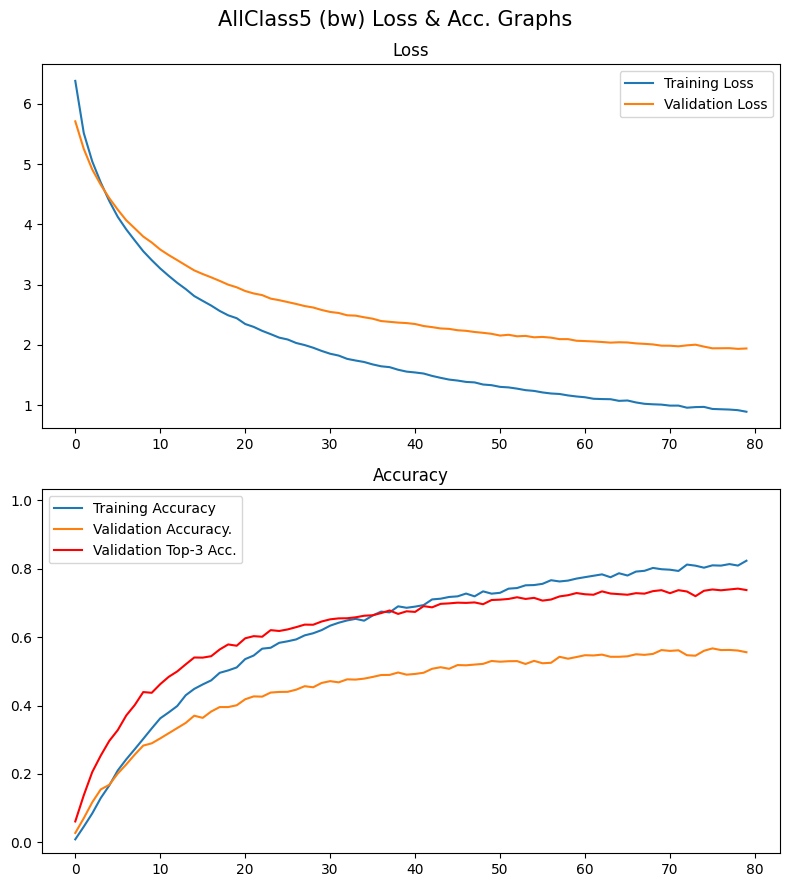

In [17]:
plt.figure(figsize=(8,9))
plt.suptitle("AllClass5 (bw) Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
bottom,top=plt.ylim()
plt.ylim(bottom,1-bottom)
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - acc: 0.5628 - loss: 2.0199 - top3_acc: 0.7319
{'acc': 0.562807023525238, 'loss': 2.0199029445648193, 'top3_acc': 0.7319298386573792}

2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step


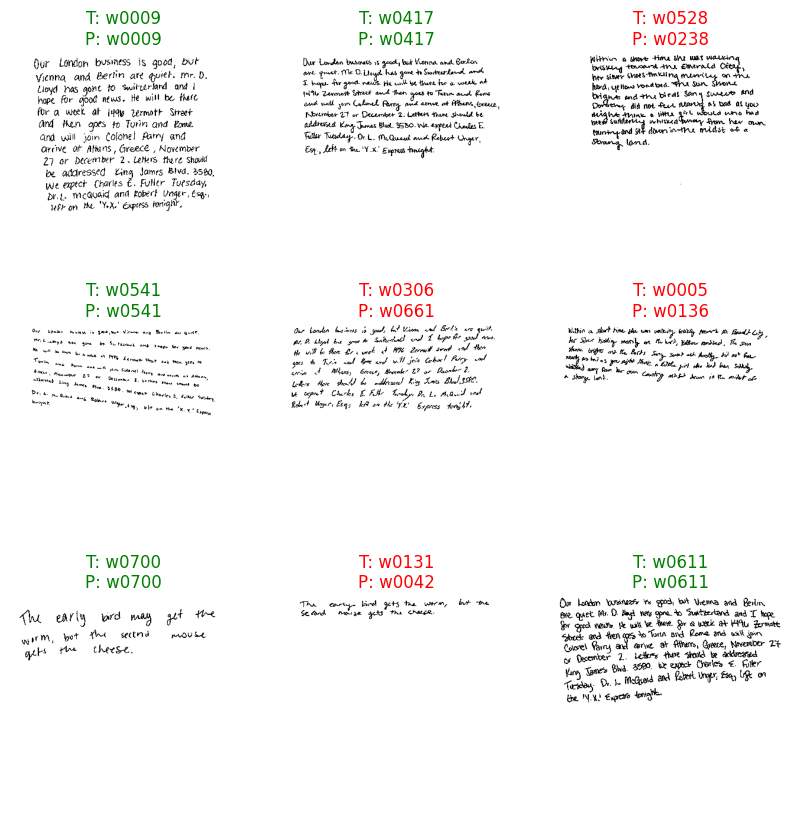

In [18]:
results = model.evaluate(test_ds, return_dict=True)

print(results)
print()

reload_data2.show_testpreds(test_ds,model)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


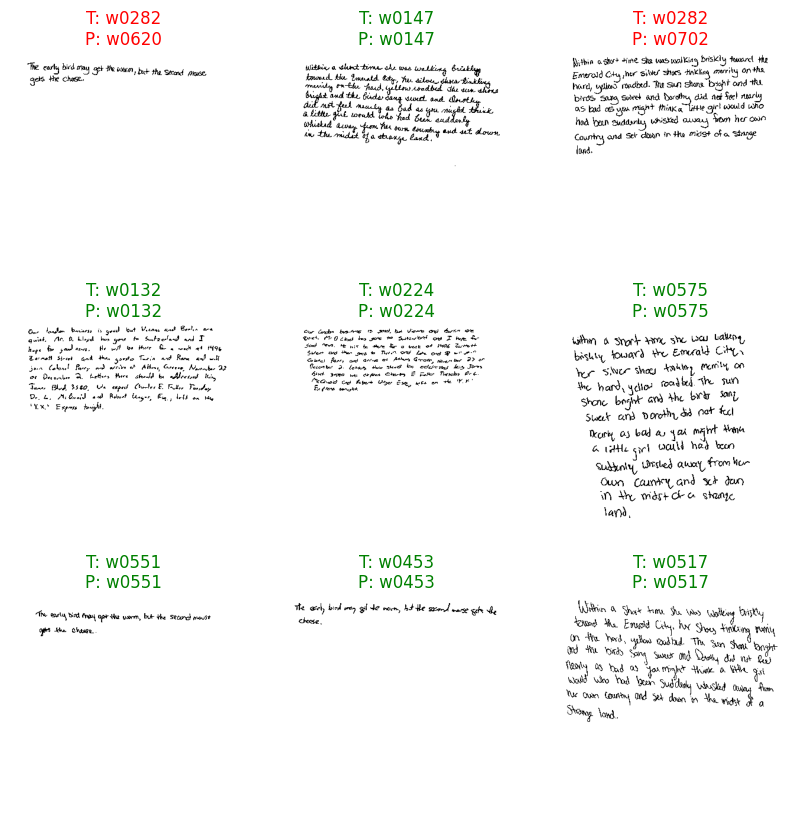

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


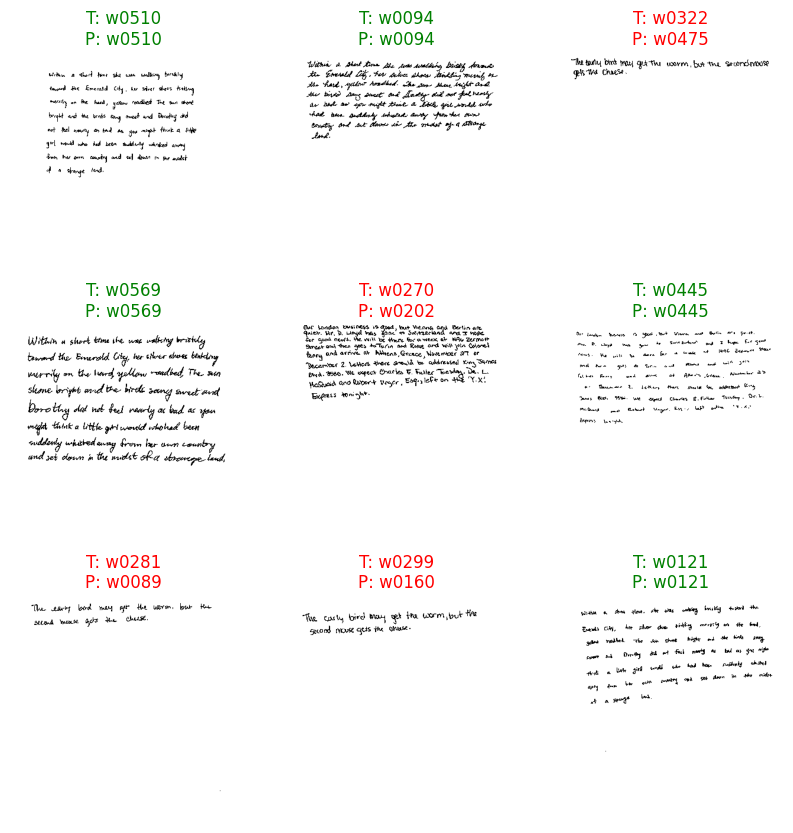

In [19]:
reload_data2.show_testpreds(test_ds,model)
reload_data2.show_testpreds(test_ds,model)

### XAI

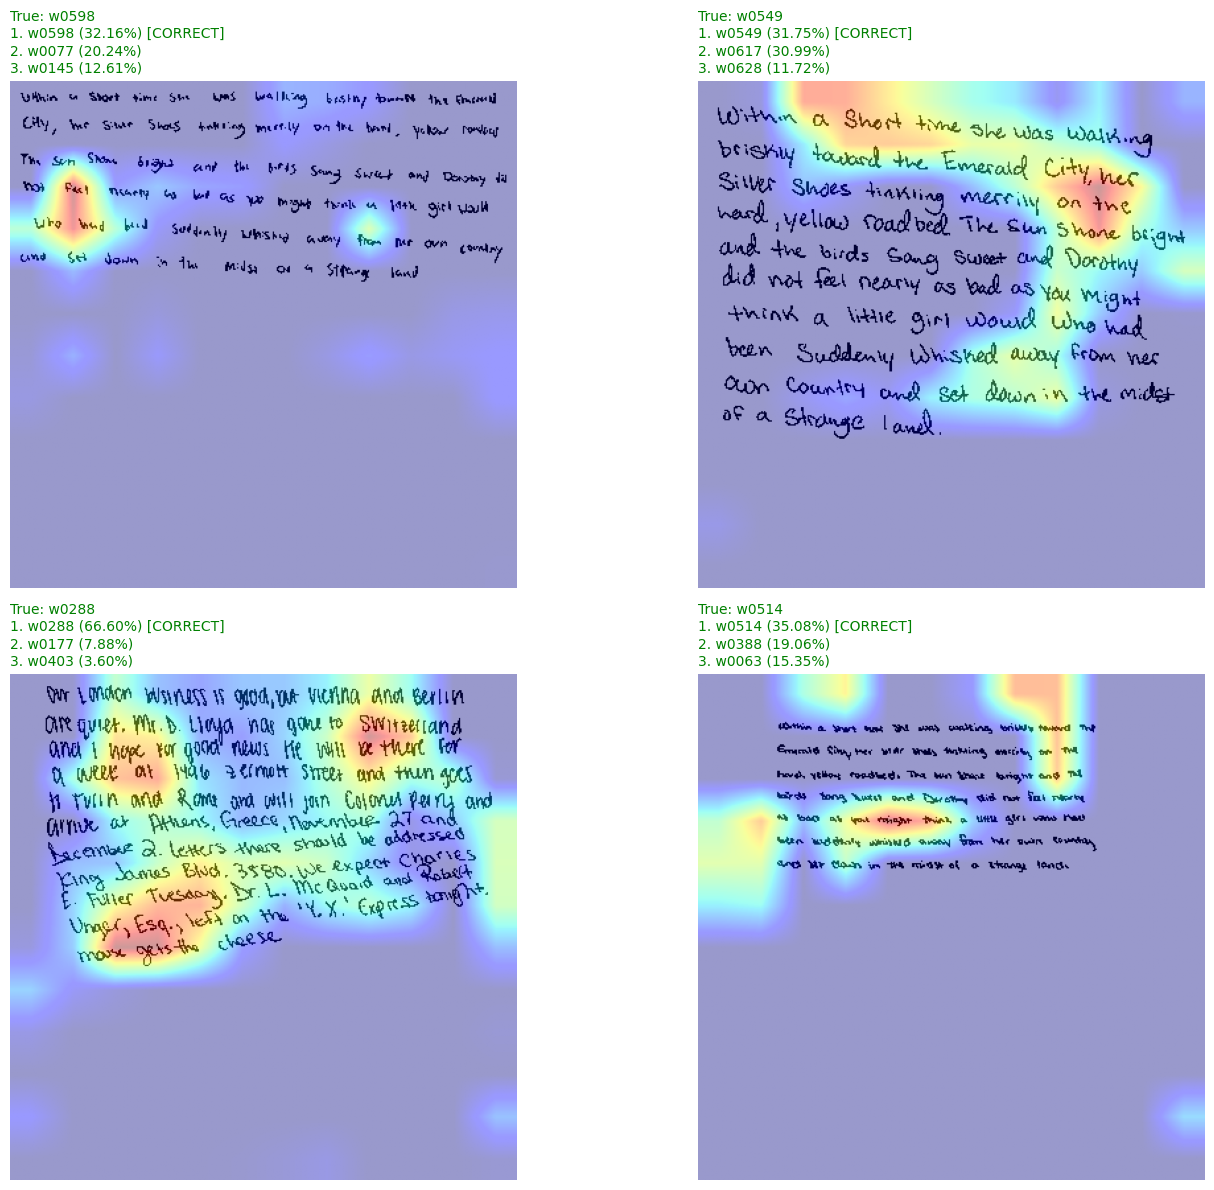

CPU times: user 15.7 s, sys: 788 ms, total: 16.5 s
Wall time: 16.7 s


In [20]:
%%time
xai.plot_gradcam_from_dataset(test_ds, model, last_conv_layer_name="out_relu", n=4)

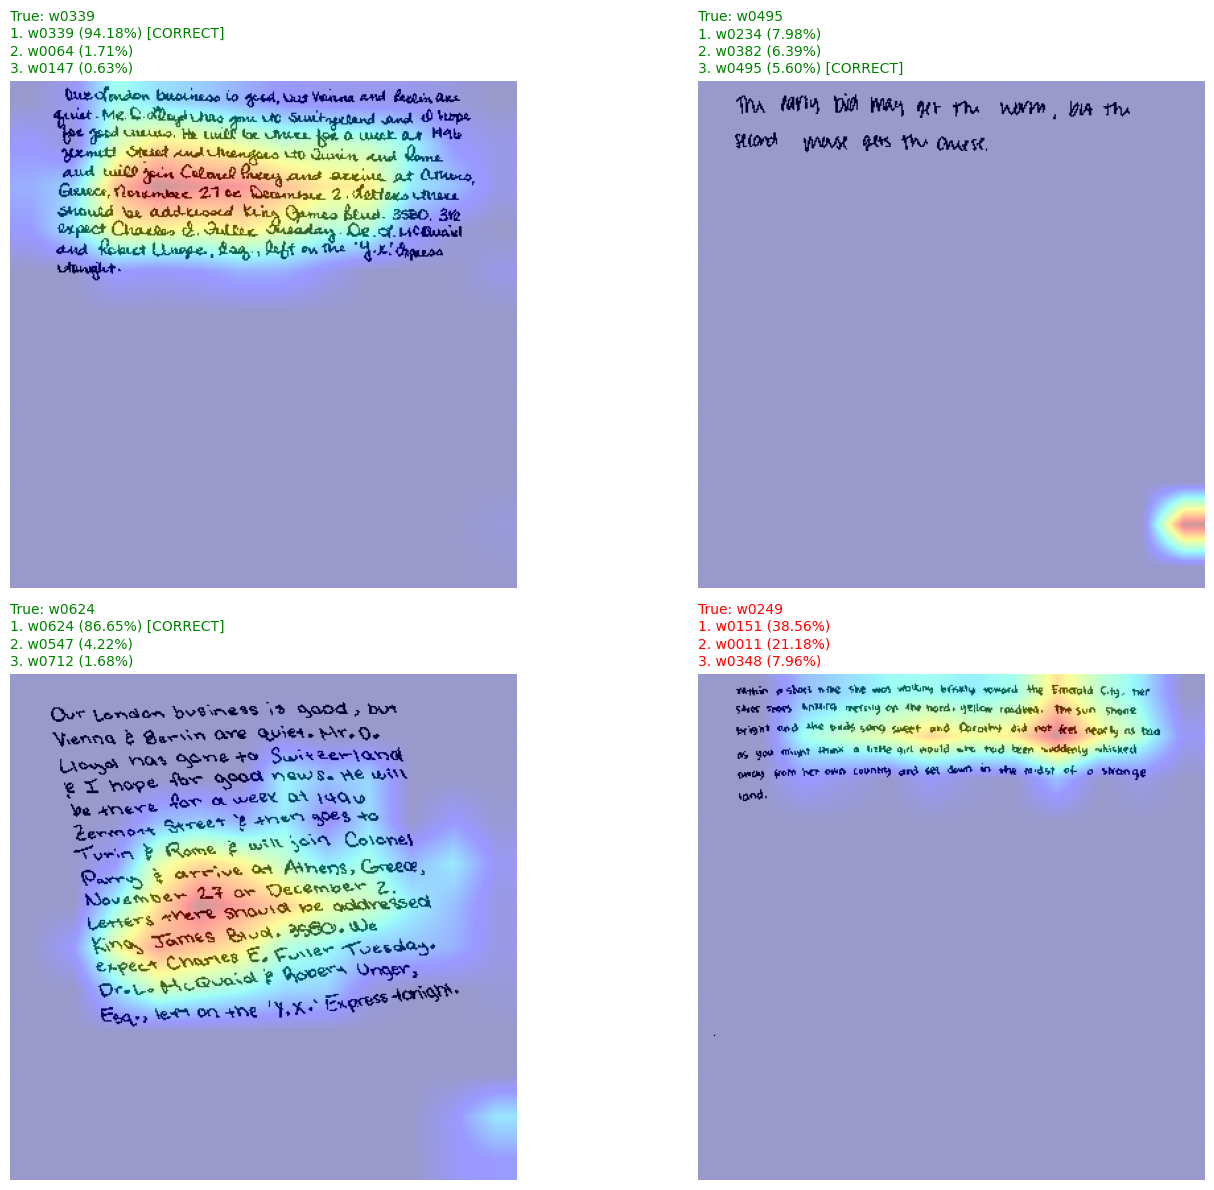

In [21]:
xai.plot_gradcam_from_dataset(test_ds, model, last_conv_layer_name="Conv_1", n=4)

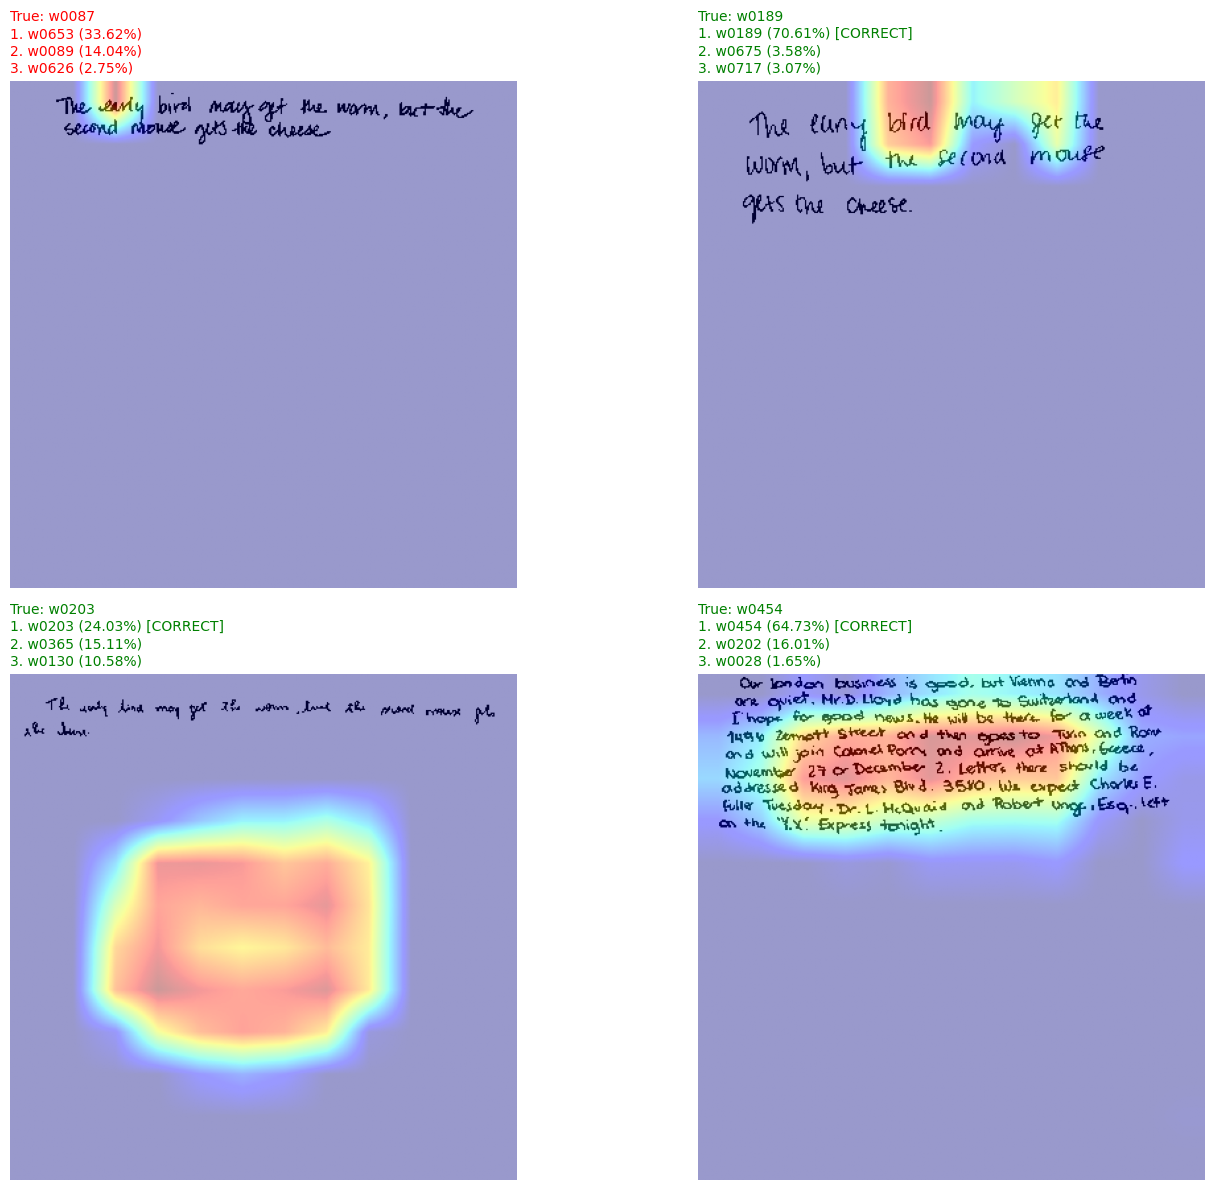

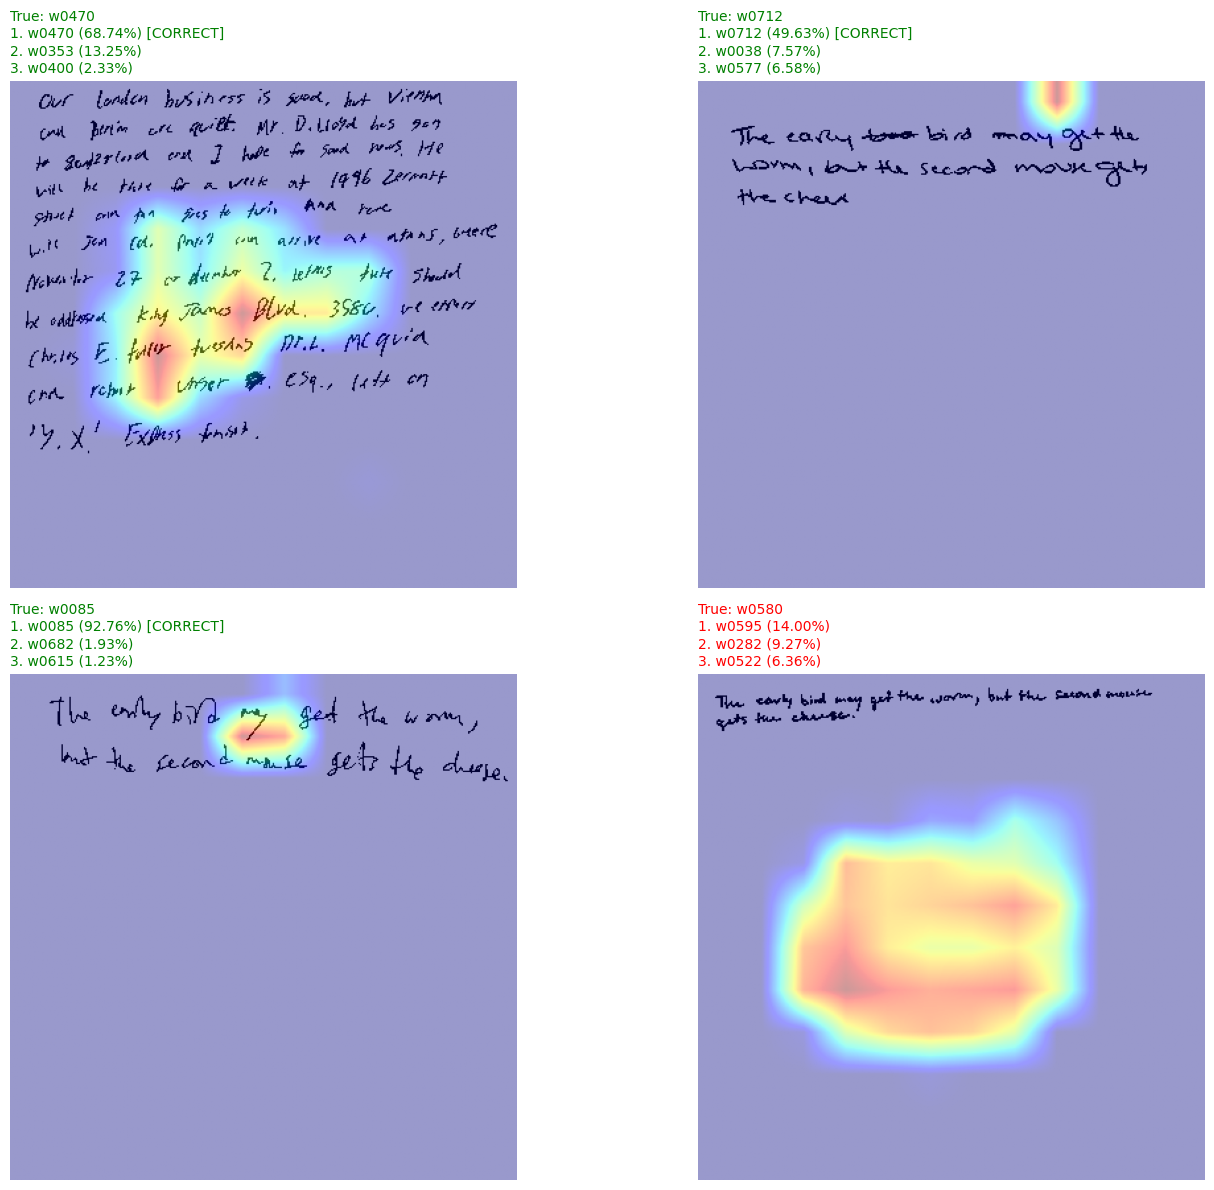

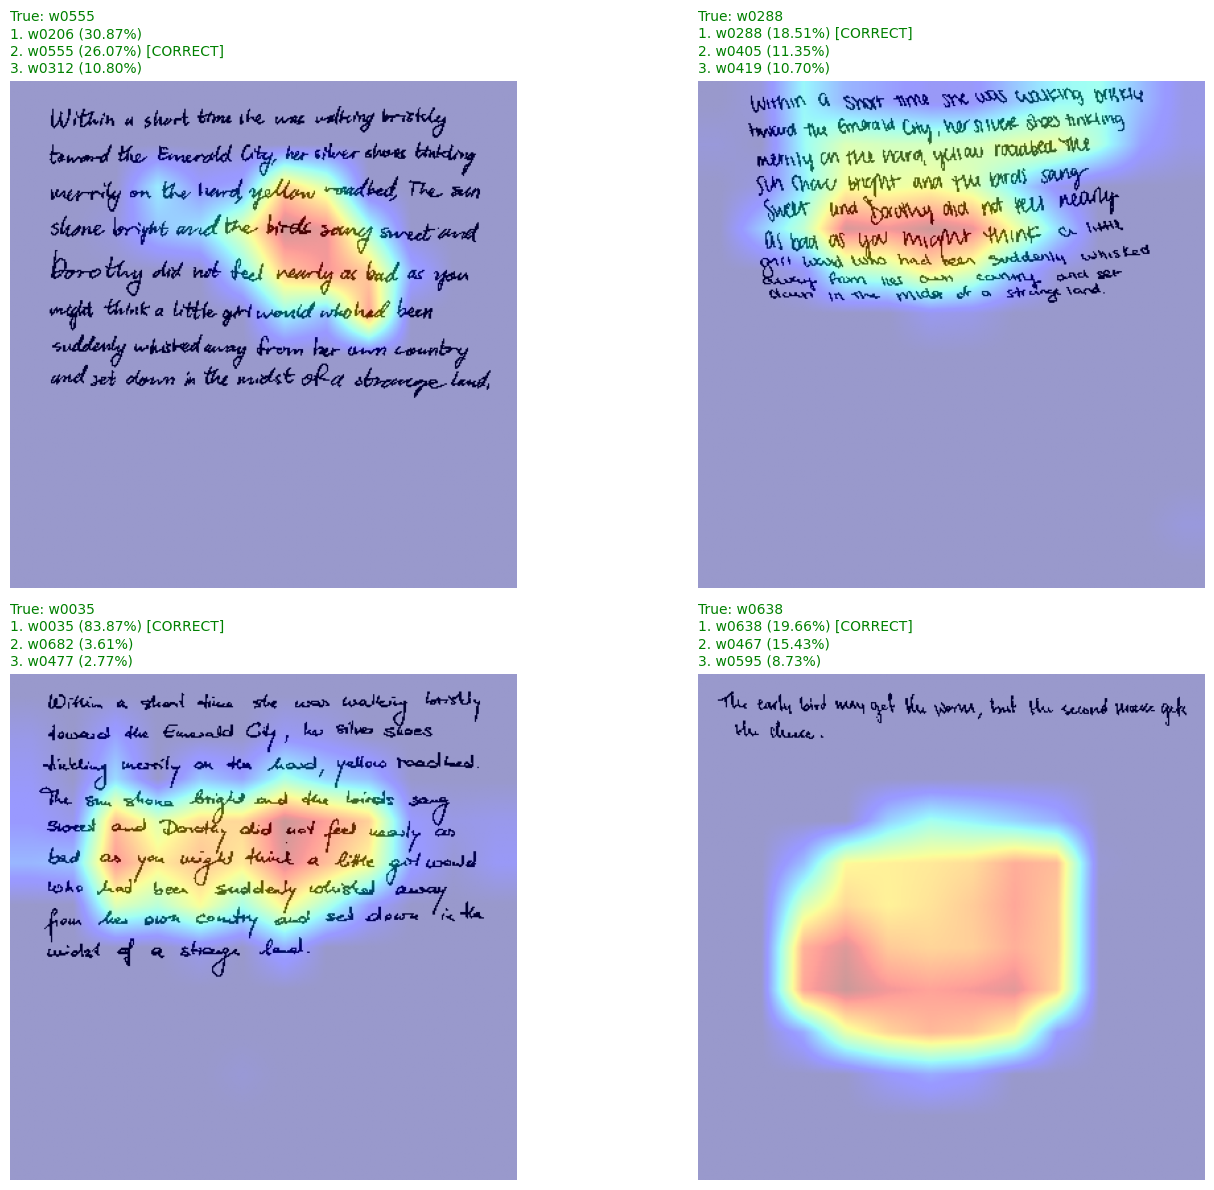

In [22]:
xai.plot_gradcam_from_dataset(test_ds, model, last_conv_layer_name="Conv_1", n=4)
xai.plot_gradcam_from_dataset(test_ds, model, last_conv_layer_name="Conv_1", n=4)
xai.plot_gradcam_from_dataset(test_ds, model, last_conv_layer_name="Conv_1", n=4)

  0%|          | 0/500 [00:00<?, ?it/s]

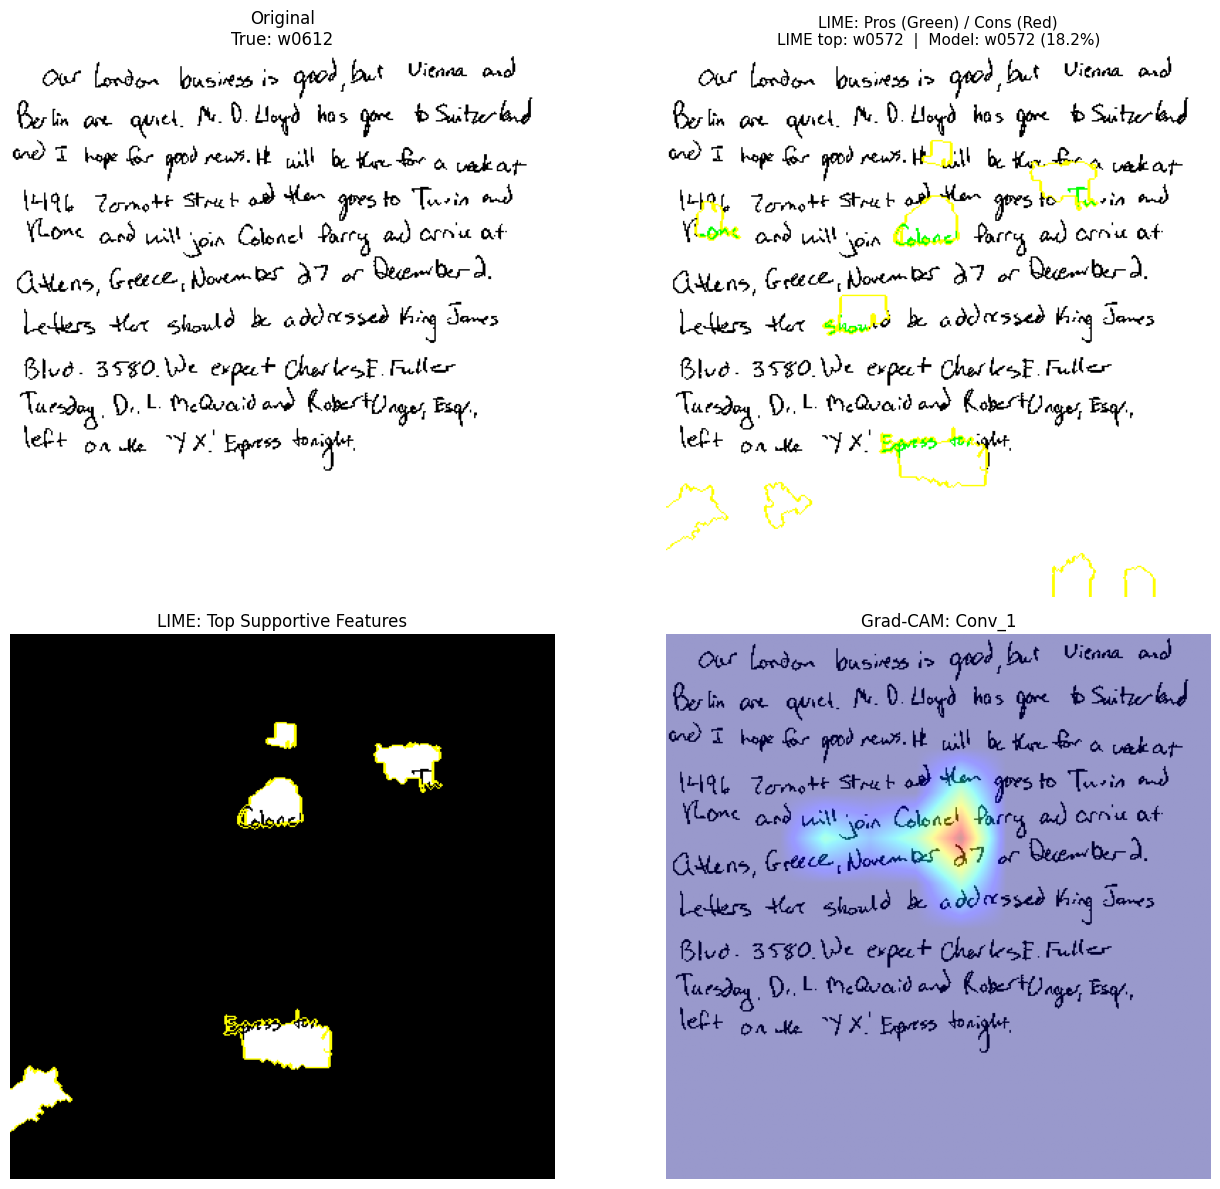

  0%|          | 0/500 [00:00<?, ?it/s]

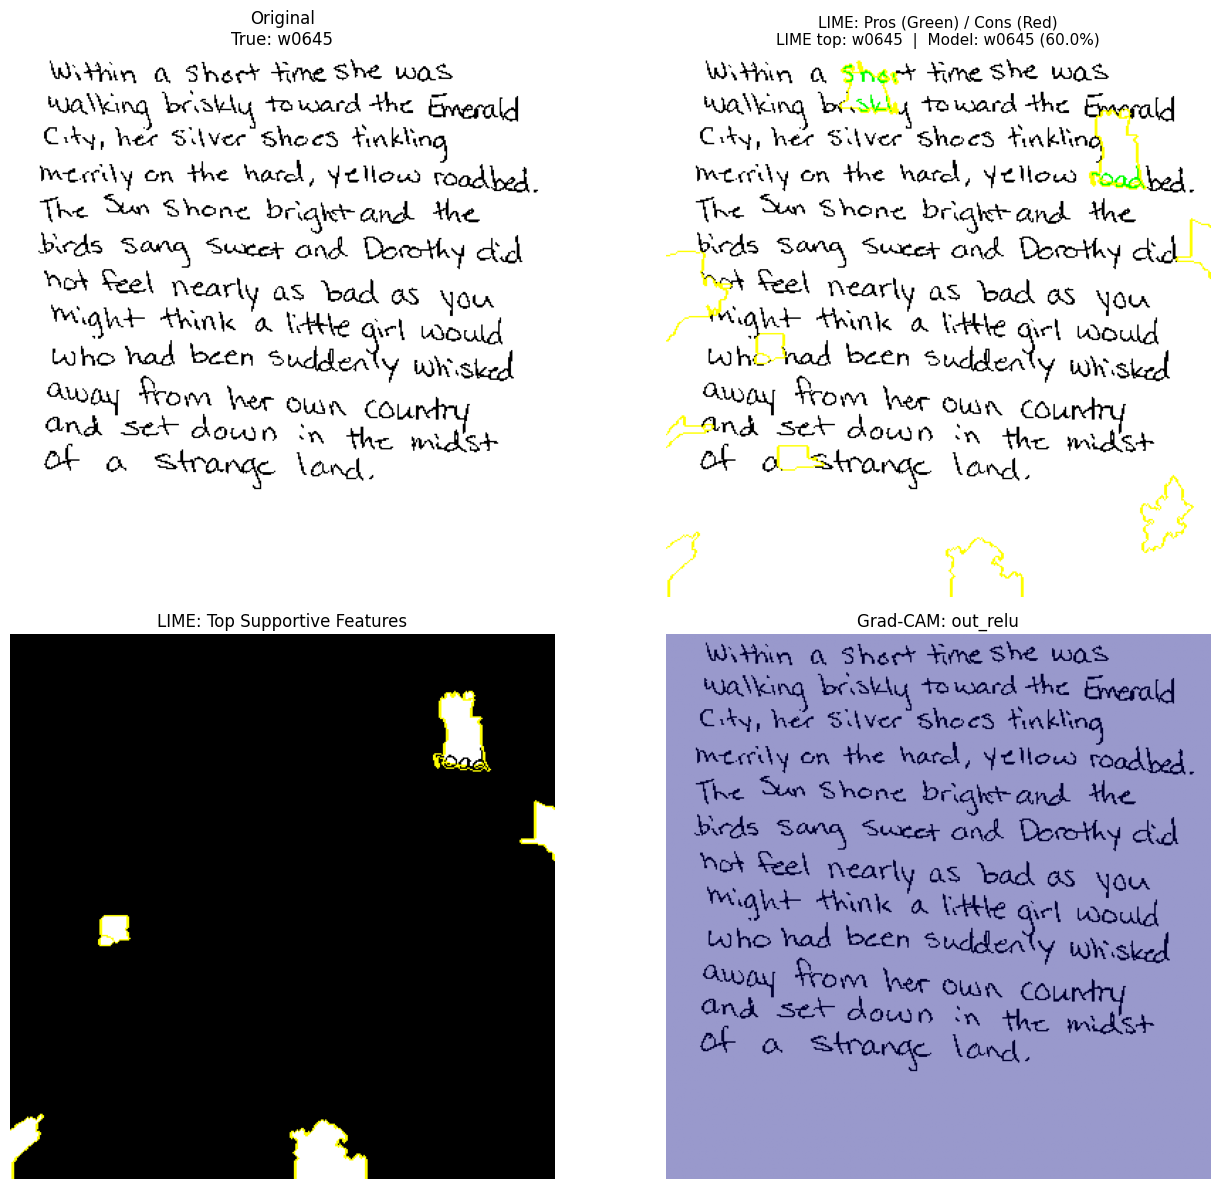

CPU times: user 30.8 s, sys: 2.99 s, total: 33.8 s
Wall time: 31.6 s


In [24]:
%%time
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")
xai.plot_ultimate_explanation(test_ds,model,"out_relu")

  0%|          | 0/500 [00:00<?, ?it/s]

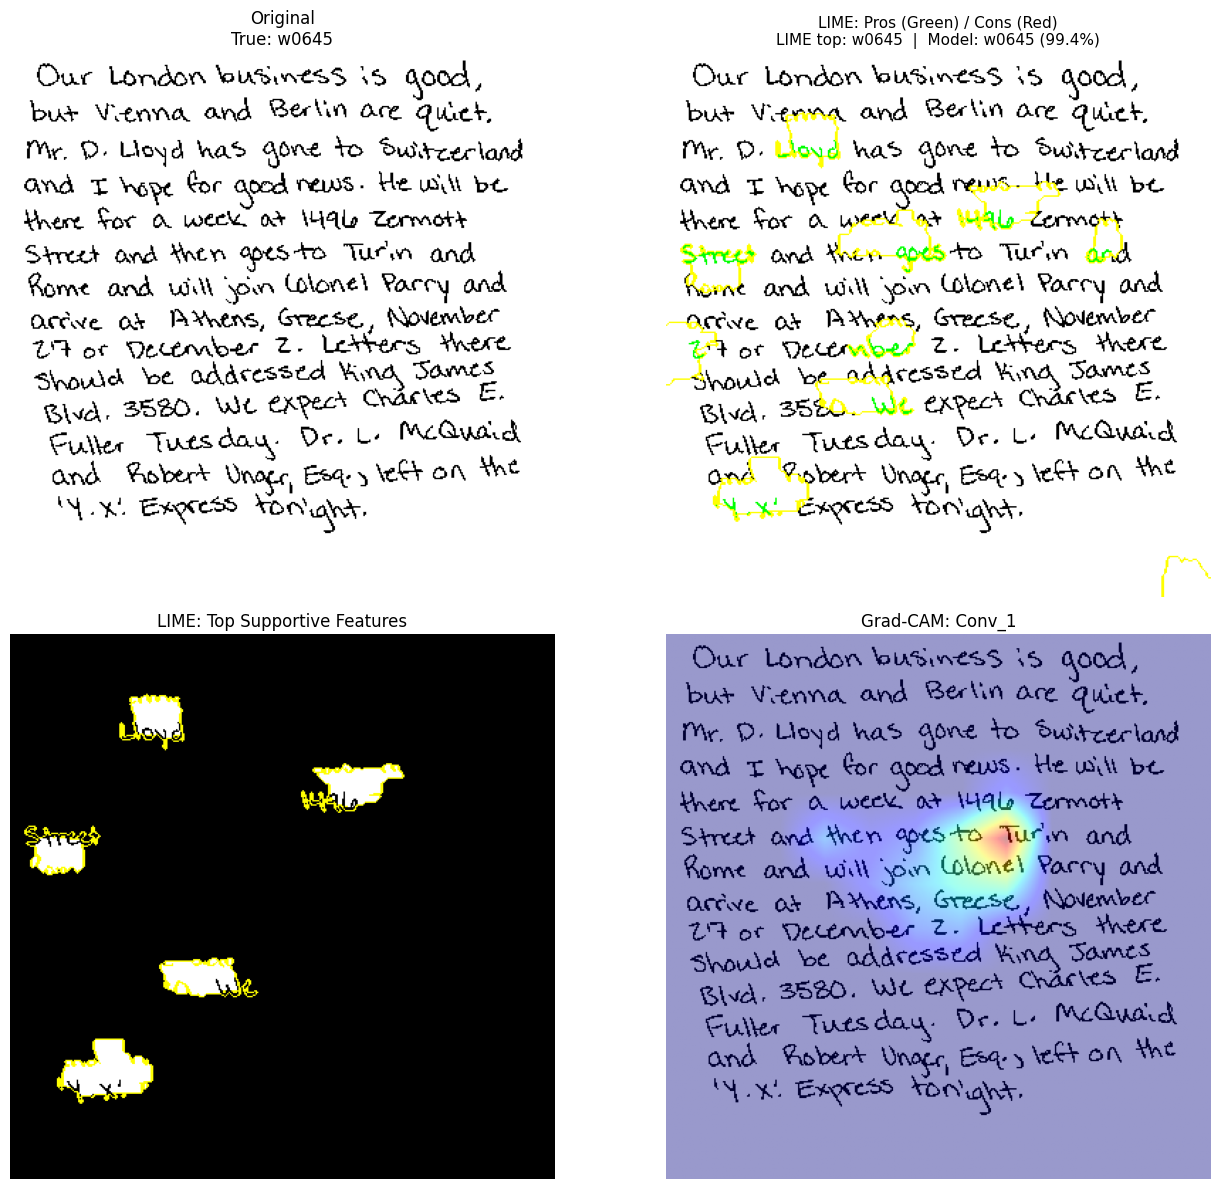

  0%|          | 0/500 [00:00<?, ?it/s]

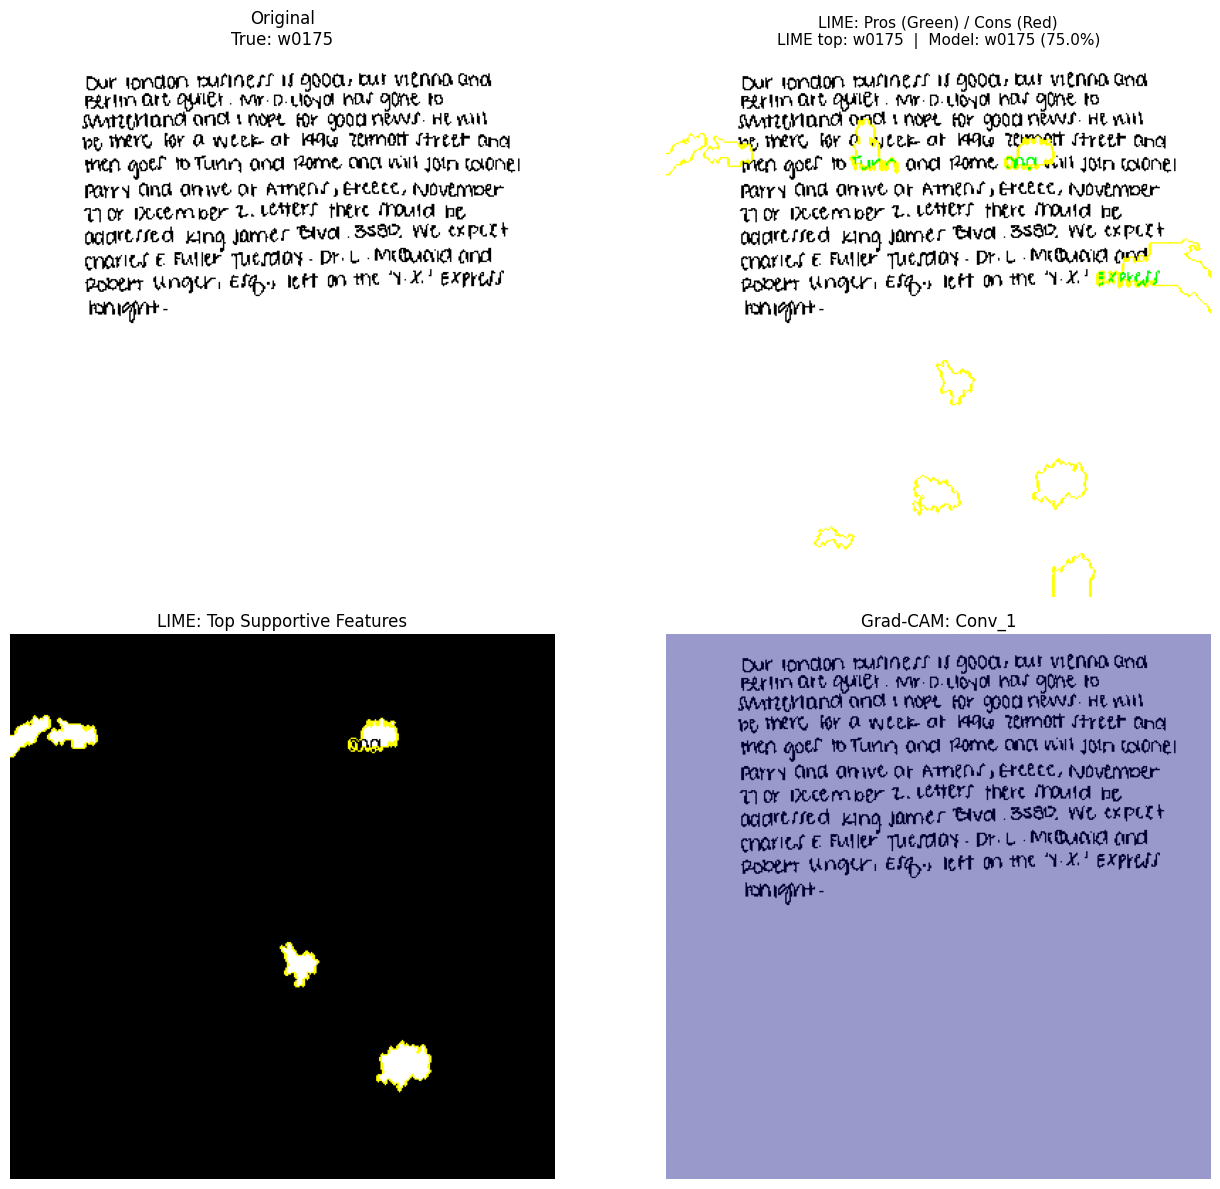

  0%|          | 0/500 [00:00<?, ?it/s]

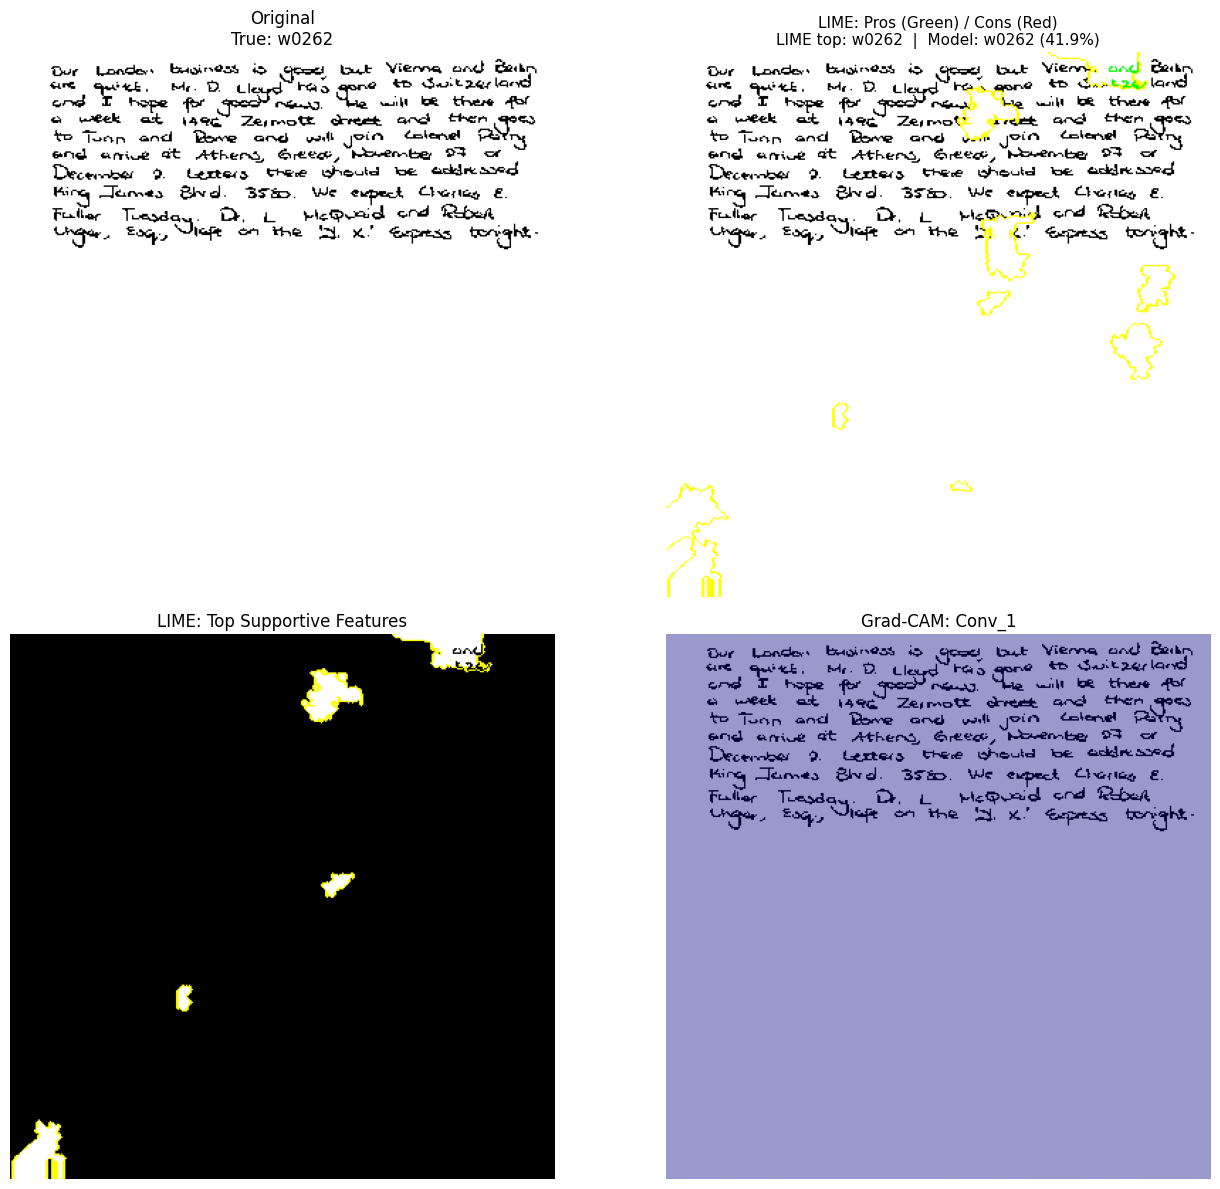

CPU times: user 46.3 s, sys: 5.04 s, total: 51.4 s
Wall time: 50 s


In [25]:
%%time
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")

  0%|          | 0/500 [00:00<?, ?it/s]

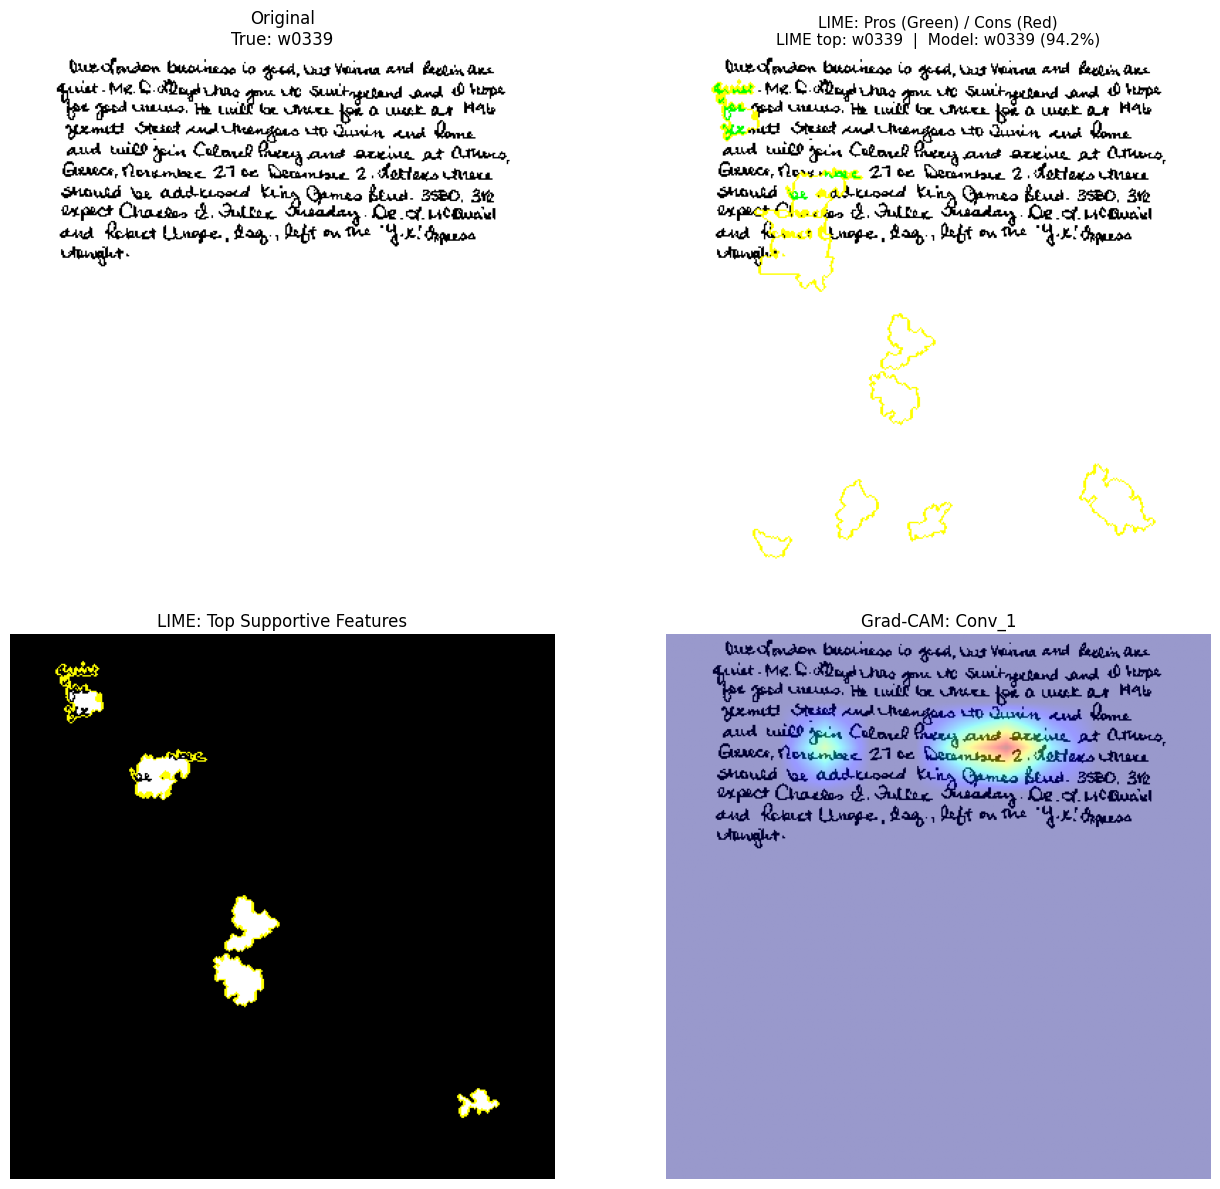

  0%|          | 0/500 [00:00<?, ?it/s]

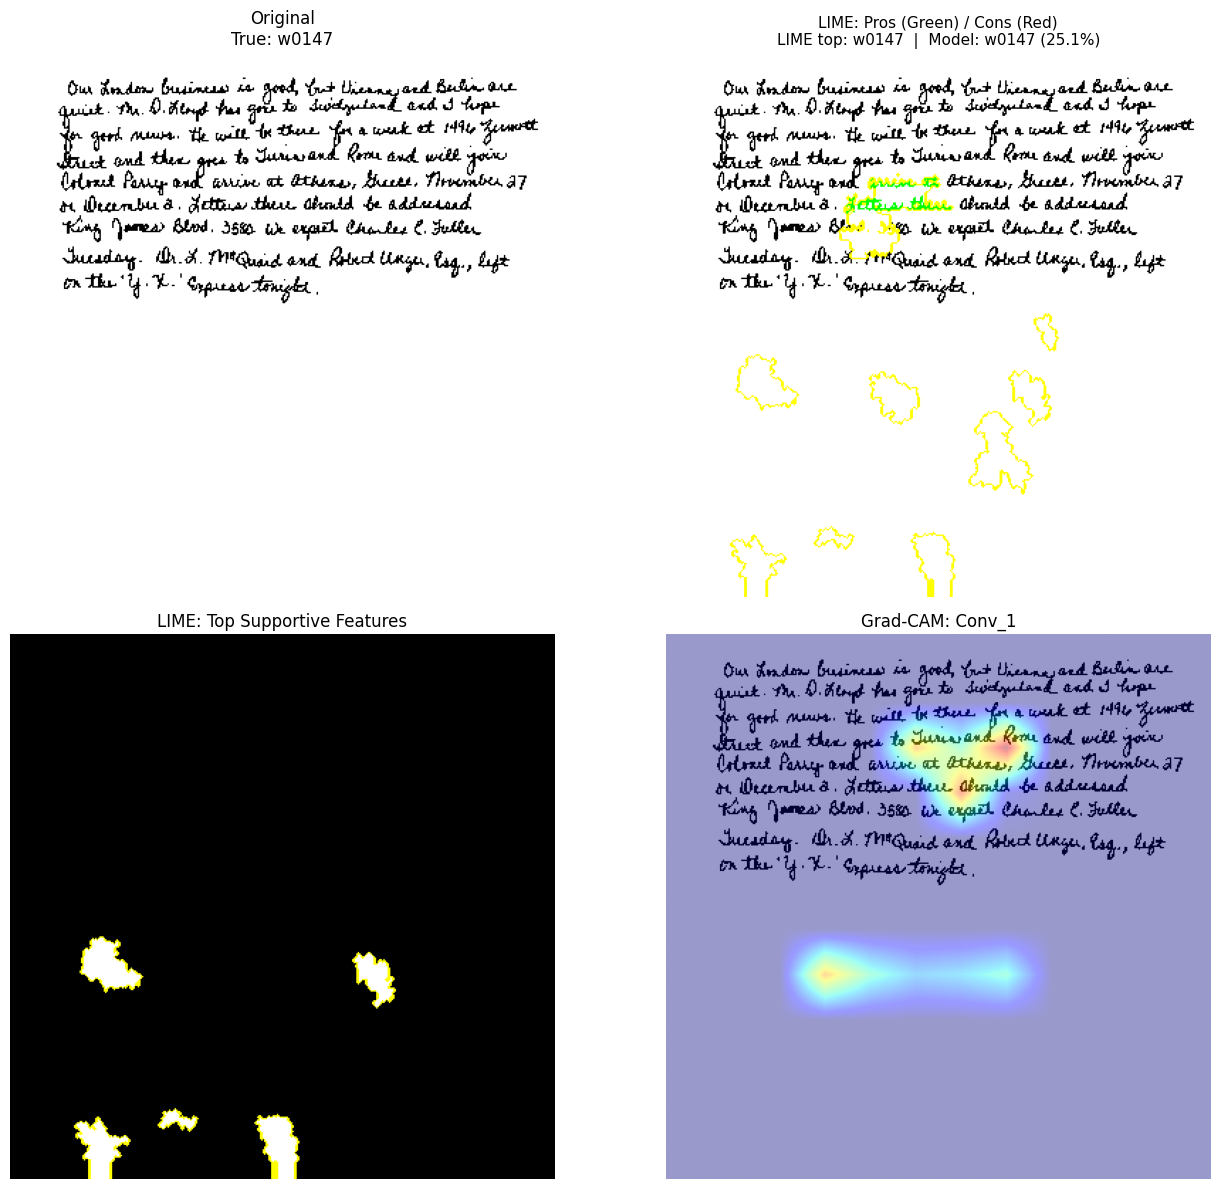

  0%|          | 0/500 [00:00<?, ?it/s]

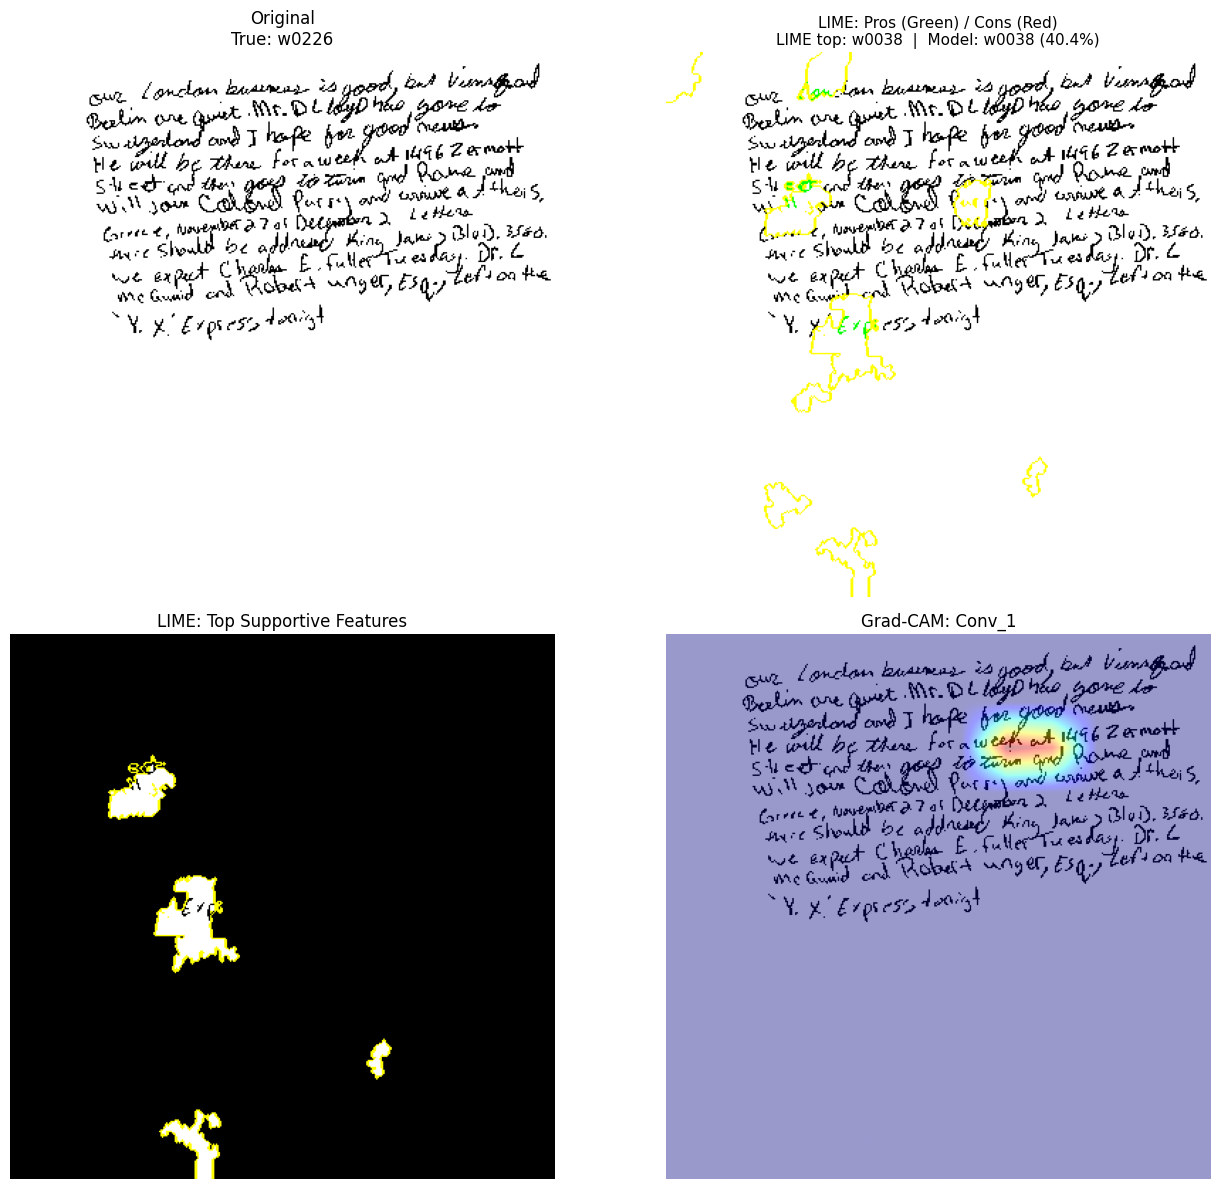

CPU times: user 49.5 s, sys: 5.03 s, total: 54.5 s
Wall time: 50.7 s


In [26]:
%%time
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1")

  0%|          | 0/500 [00:00<?, ?it/s]

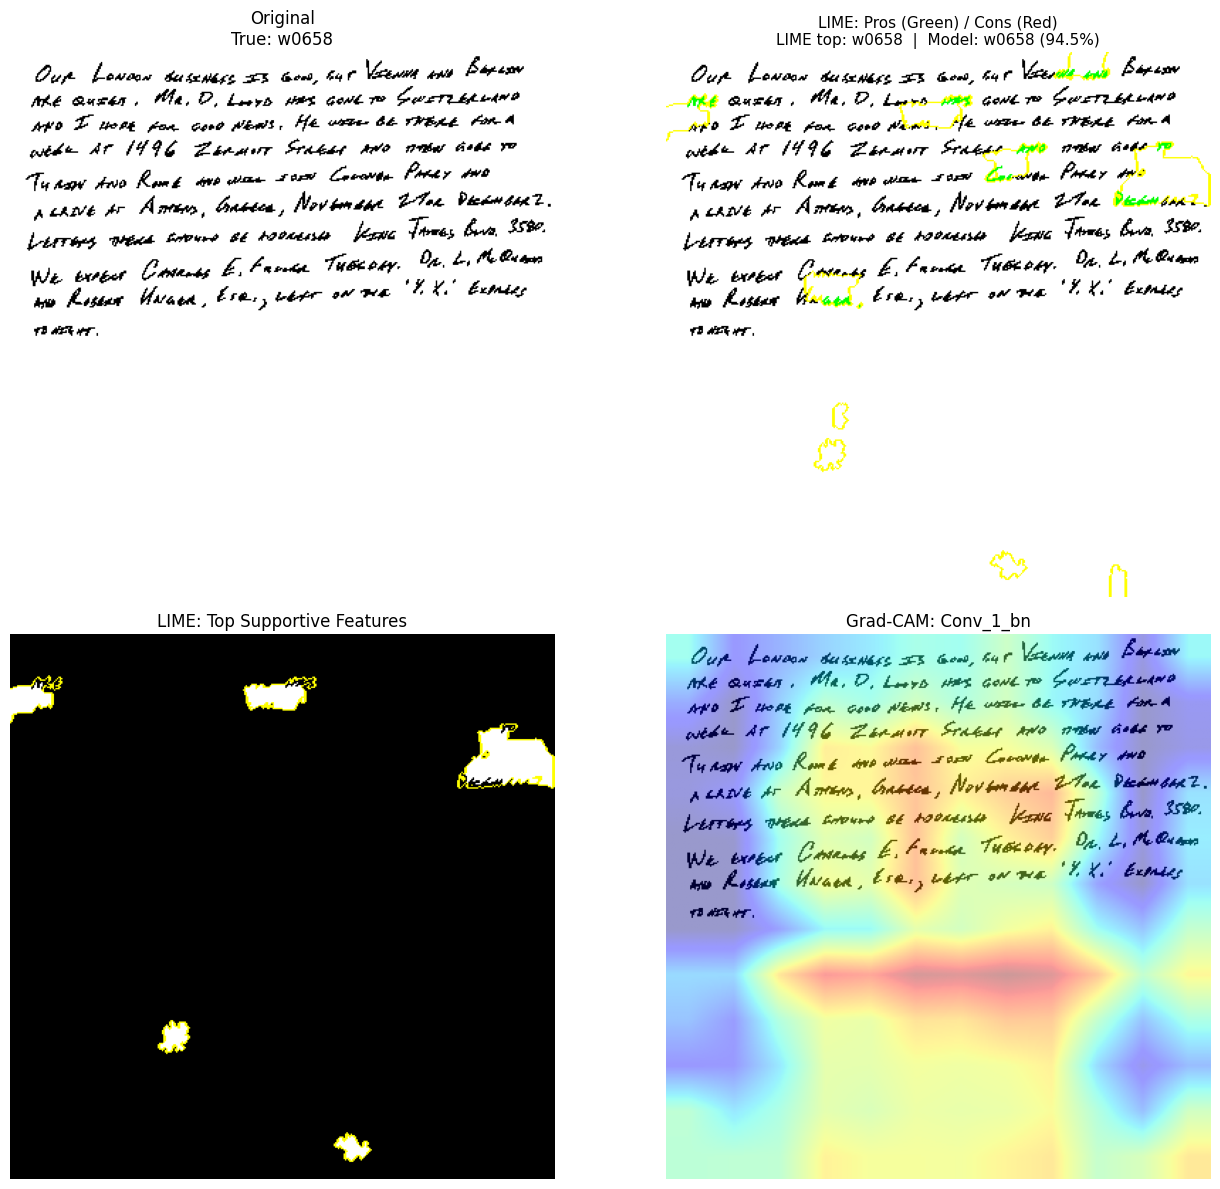

  0%|          | 0/500 [00:00<?, ?it/s]

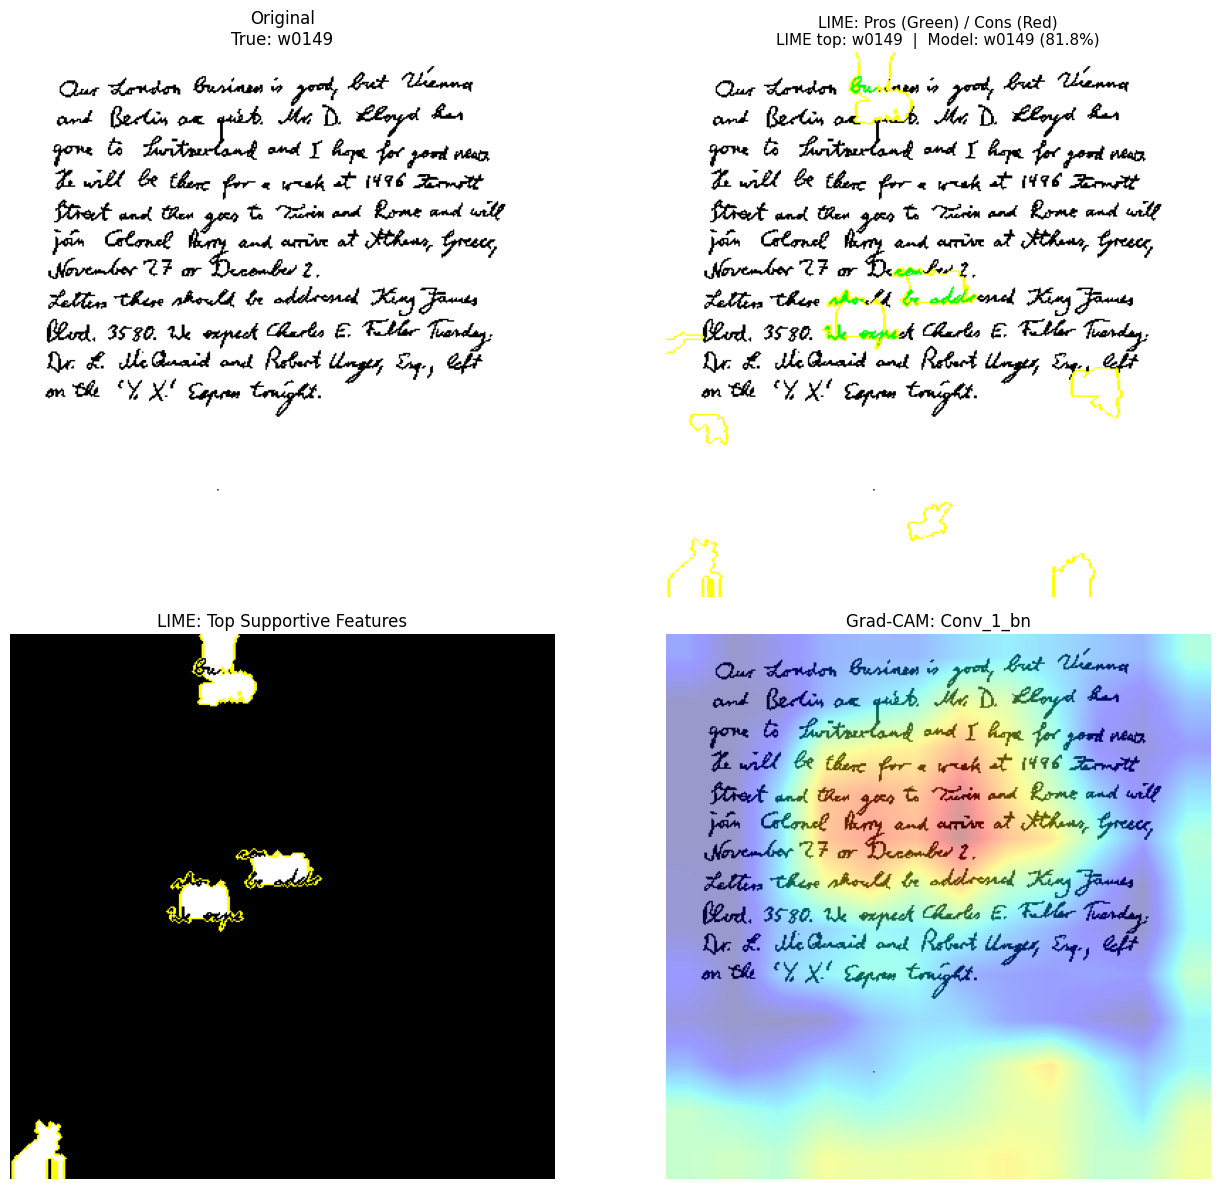

  0%|          | 0/500 [00:00<?, ?it/s]

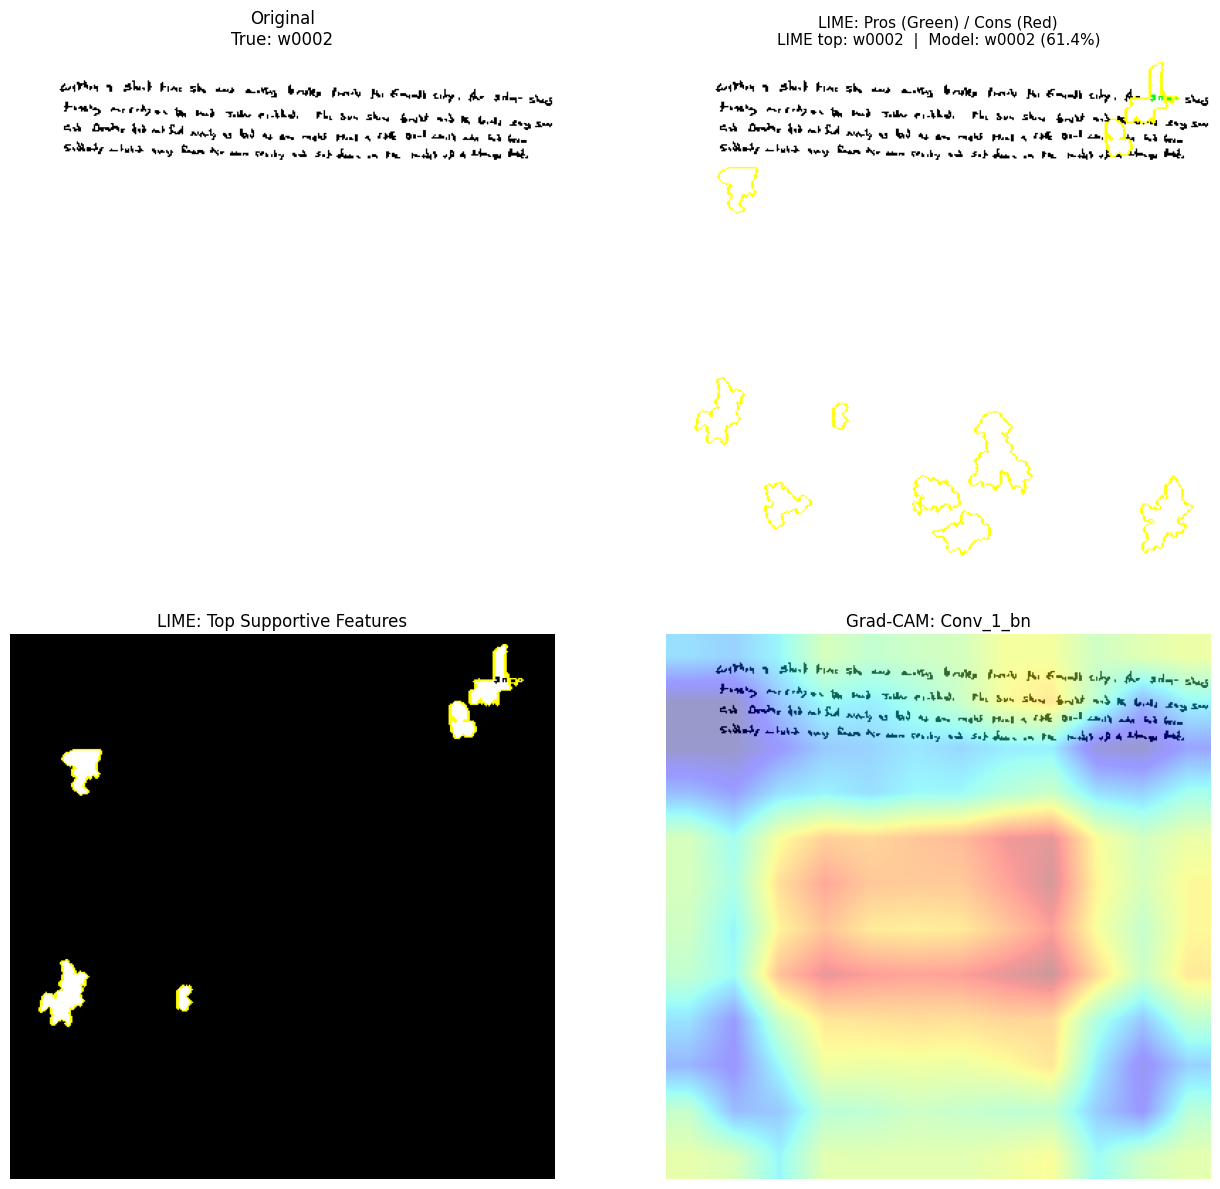

CPU times: user 49.3 s, sys: 5.1 s, total: 54.4 s
Wall time: 51 s


In [28]:
%%time
xai.plot_ultimate_explanation(test_ds,model,"Conv_1_bn")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1_bn")
xai.plot_ultimate_explanation(test_ds,model,"Conv_1_bn")